In [7]:
import IPython.display as ipyd
from pyspark.sql.functions import col, regexp_replace, monotonically_increasing_id
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import col, monotonically_increasing_id, regexp_replace


In [8]:

spark = SparkSession.builder.getOrCreate()
df = spark.read.parquet("/home/iceberg/data/compras")
df = df.withColumn("id", monotonically_increasing_id())

df_typecasted = df.withColumn("ano", col("ano").cast("int")) \
                  .withColumn("mes", col("mes").cast("int")) \
                  .withColumn("Quantidade Item", col("Quantidade Item").cast("float")) \
                  .withColumn("Valor Item", regexp_replace(col("Valor Item"), ",", ".").cast("float"))

ids_to_remove = [25770005293, 25770005295]
df_typecasted = df_typecasted.filter(~col("id").isin(ids_to_remove))  # fix: col("id") not df["id"]

cardinality = sorted([
    (column, df_typecasted.select(F.approx_count_distinct(column)).collect()[0][0])
    for column in df_typecasted.columns if column != "id"
], key=lambda x: x[1])

ordered_cols = [c for c, _ in cardinality]

df_final = df_typecasted.select(ordered_cols) \
                        .orderBy(*[c for c, _ in cardinality])

In [9]:
spark.sql("CREATE NAMESPACE IF NOT EXISTS demo.compras")

df_final.writeTo("demo.compras.compras") \
        .tableProperty("format-version", "2") \
        .partitionedBy("ano", "mes") \
        .createOrReplace()

In [10]:
df_typecasted.printSchema()

root
 |-- Código Órgão: string (nullable = true)
 |-- Nome Órgão: string (nullable = true)
 |-- Código UG: string (nullable = true)
 |-- Nome UG: string (nullable = true)
 |-- Número Contrato: string (nullable = true)
 |-- Código Item Compra: string (nullable = true)
 |-- Descrição Item Compra: string (nullable = true)
 |-- Descrição Complementar Item Compra: string (nullable = true)
 |-- Quantidade Item: float (nullable = true)
 |-- Valor Item: float (nullable = true)
 |-- ano: integer (nullable = true)
 |-- mes: integer (nullable = true)
 |-- id: long (nullable = false)



---

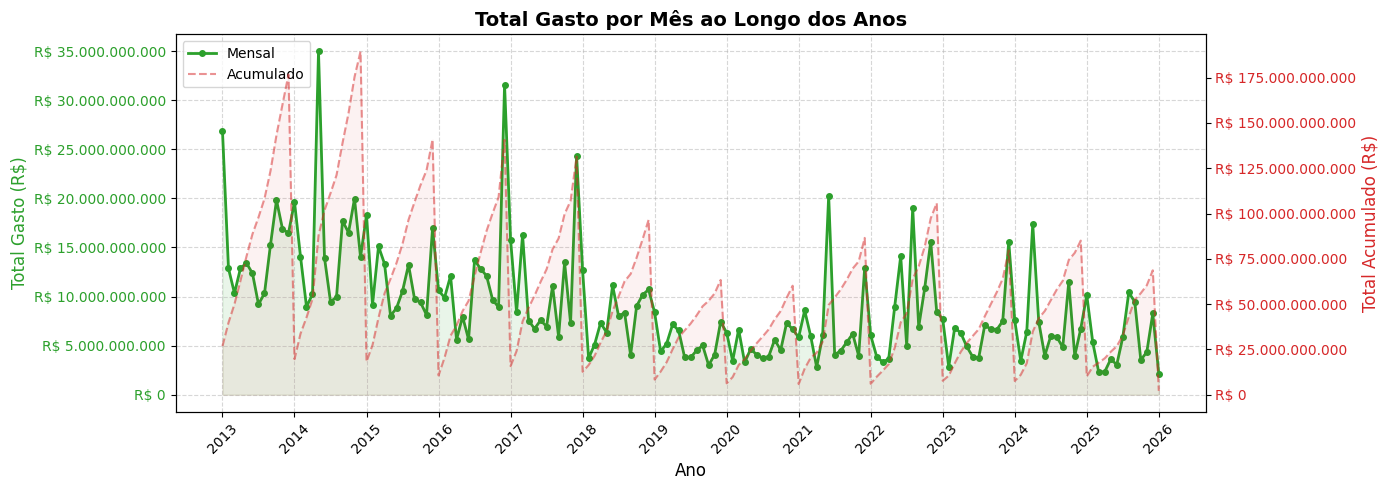

In [11]:
import matplotlib.pyplot as plt
from pyspark.sql.functions import sum as spark_sum, col

pdf = (
    df_typecasted
      .filter(
          (col("Valor Item") > 0) &
          (col("Quantidade Item") > 0) &
          (~col("id").isin([25770005293, 25770005295]))
      )
      .groupBy("ano", "mes")
      .agg(spark_sum("Valor Item").alias("total_valor"))
      .orderBy("ano", "mes")
      .toPandas()
)

pdf["month_index"] = (pdf["ano"] - pdf["ano"].min()) * 12 + (pdf["mes"] - 1)

pdf["cumsum_valor"] = pdf.groupby("ano")["total_valor"].cumsum()

fig, ax = plt.subplots(figsize=(14, 5))

ax2 = ax.twinx()
ax2.fill_between(pdf["month_index"], pdf["cumsum_valor"], alpha=0.06, color="#d62728")
ax2.plot(pdf["month_index"], pdf["cumsum_valor"], linewidth=1.5, color="#d62728", linestyle="--", alpha=0.5, label="Acumulado")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"R$ {x:,.0f}".replace(",", ".")))
ax2.set_ylabel("Total Acumulado (R$)", fontsize=12, color="#d62728")
ax2.tick_params(axis="y", labelcolor="#d62728")

ax.plot(pdf["month_index"], pdf["total_valor"], marker="o", linewidth=2, color="#2ca02c", markersize=4, label="Mensal", zorder=3)
ax.fill_between(pdf["month_index"], pdf["total_valor"], alpha=0.1, color="#2ca02c")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"R$ {x:,.0f}".replace(",", ".")))
ax.set_ylabel("Total Gasto (R$)", fontsize=12, color="#2ca02c")
ax.tick_params(axis="y", labelcolor="#2ca02c")

years = pdf.drop_duplicates("ano").sort_values("ano")
tick_positions = ((years["ano"] - pdf["ano"].min()) * 12).tolist()
tick_labels = years["ano"].astype(str).tolist()
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45)

ax.set_title("Total Gasto por Mês ao Longo dos Anos", fontsize=14, fontweight="bold")
ax.set_xlabel("Ano", fontsize=12)
ax.grid(True, linestyle="--", alpha=0.5)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()

In [22]:
import numpy as np
import pandas as pd
from pyspark.sql.window import Window

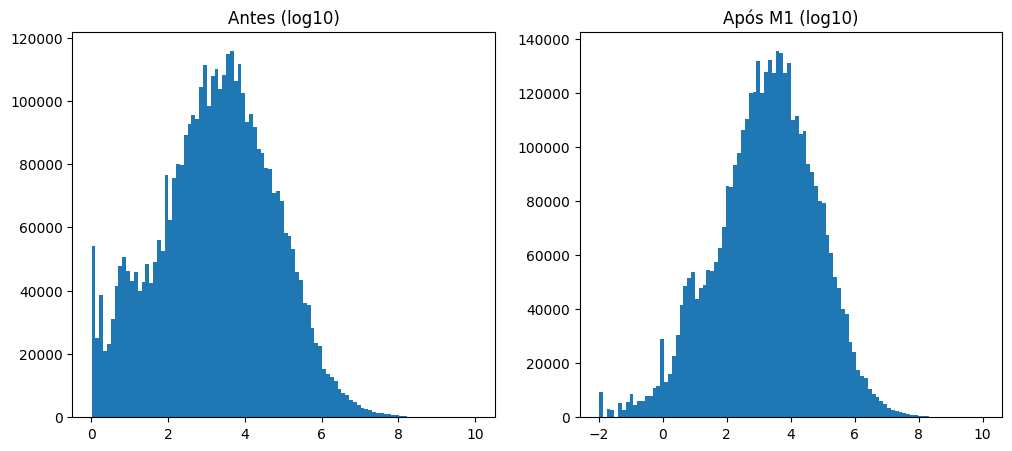

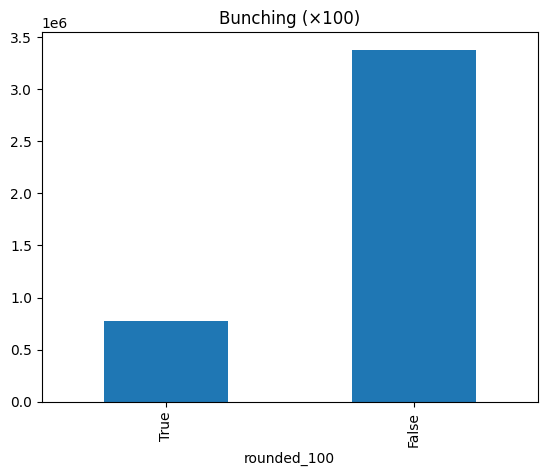

In [14]:
# =========================================
# M1 — ELIGIBILITY FILTER
# =========================================
df_model = (
    df_typecasted
    .filter((col("Valor Item") > 0) & (col("Quantidade Item") > 0))
    .withColumnRenamed("Valor Item", "value")
)

# LOG SAFE
df_model = df_model.withColumn("log_value", F.log10(col("value")))

# -------- VISUALIZAÇÃO M1 --------
pdf_raw = df_typecasted.select("Valor Item").dropna().toPandas()
pdf_model = df_model.select("value", "log_value").dropna().toPandas()

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
pdf_raw = pdf_raw[pdf_raw["Valor Item"] > 0]  # remove zero e negativos
pdf_raw = pdf_raw.dropna()
plt.hist(np.log10(pdf_raw["Valor Item"] + 1), bins=100)
plt.title("Antes (log10)")

plt.subplot(1,2,2)
plt.hist(pdf_model["log_value"], bins=100)
plt.title("Após M1 (log10)")

plt.show()

# BUNCHING
df_model.withColumn("rounded_100", col("value") % 100 == 0) \
    .groupBy("rounded_100") \
    .count() \
    .toPandas() \
    .set_index("rounded_100") \
    .plot(kind="bar", legend=False)

plt.title("Bunching (×100)")
plt.show()

In [15]:
# =========================================
# HELPERS
# =========================================
def first_digit():
    return F.substring(F.regexp_replace(col("value").cast("string"), "[^0-9]", ""), 1, 1).cast("int")

def first_two_digits():
    return F.substring(F.regexp_replace(col("value").cast("string"), "[^0-9]", ""), 1, 2).cast("int")

def last_digit():
    return (col("value") % 10).cast("int")

# =========================================
# FEATURE ENGINEERING
# =========================================
df_feat = df_model \
    .withColumn("d1", first_digit()) \
    .withColumn("d2", first_two_digits()) \
    .withColumn("ld", last_digit())

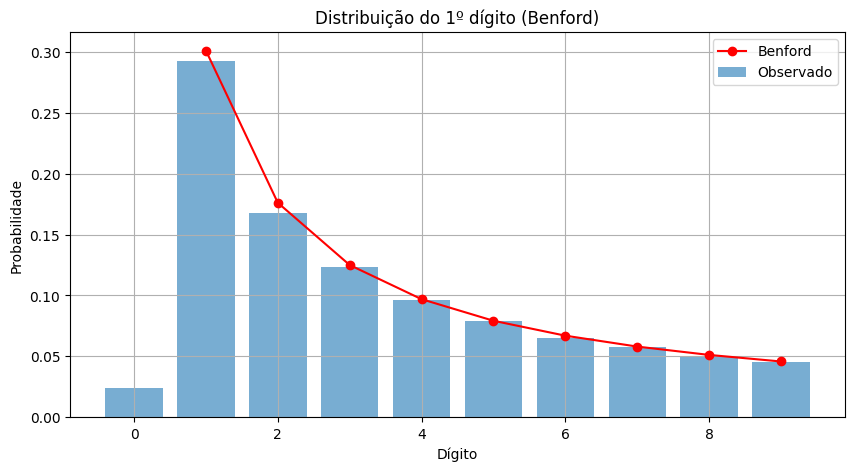

In [17]:
df1 = df_feat.withColumn("digit", first_digit())

obs = df1.groupBy("digit").count().orderBy("digit").toPandas()
obs["p_obs"] = obs["count"] / obs["count"].sum()

exp = pd.DataFrame({
    "digit": list(range(1,10)),
    "p_exp": [np.log10(1+1/d) for d in range(1,10)]
})

plt.figure(figsize=(10,5))
plt.bar(obs["digit"], obs["p_obs"], alpha=0.6, label="Observado")
plt.plot(exp["digit"], exp["p_exp"], color="red", marker="o", label="Benford")
plt.title("Distribuição do 1º dígito (Benford)")
plt.xlabel("Dígito")
plt.ylabel("Probabilidade")
plt.legend()
plt.grid()
plt.show()

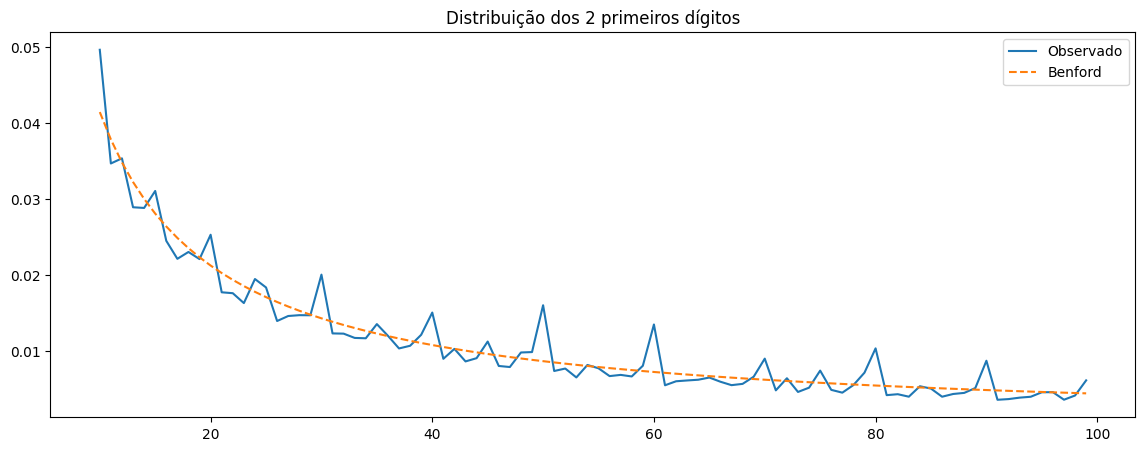

In [19]:
df2 = df_feat.withColumn("digit", first_two_digits()).filter(col("digit").between(10,99))

obs2 = df2.groupBy("digit").count().orderBy("digit").toPandas()
obs2["p_obs"] = obs2["count"] / obs2["count"].sum()

exp2 = pd.DataFrame({
    "digit": list(range(10,100)),
    "p_exp": [np.log10(1+1/n) for n in range(10,100)]
})

plt.figure(figsize=(14,5))
plt.plot(obs2["digit"], obs2["p_obs"], label="Observado")
plt.plot(exp2["digit"], exp2["p_exp"], label="Benford", linestyle="--")
plt.title("Distribuição dos 2 primeiros dígitos")
plt.legend()
plt.show()

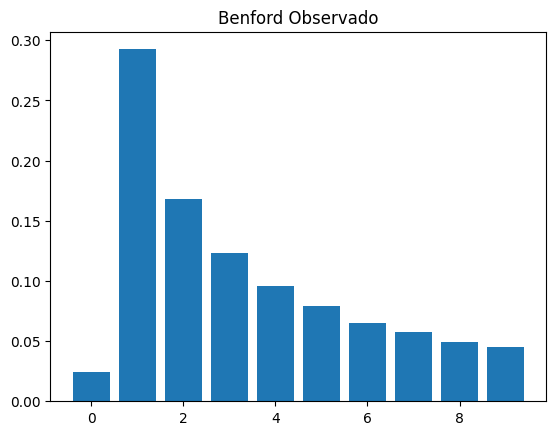

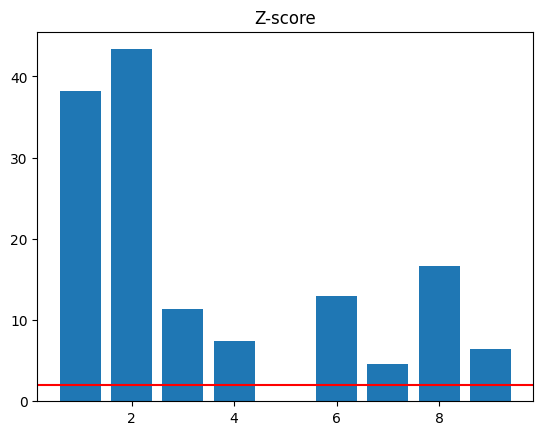

In [20]:

# =========================================
# M2 — STATISTICAL ENGINE
# =========================================
benford_1d = spark.createDataFrame([
    (d, float(np.log10(1 + 1/d))) for d in range(1, 10)
], ["d1", "p_exp_1d"])

obs_df = df_feat.groupBy("d1").count().withColumnRenamed("count", "O")
N = obs_df.agg(F.sum("O")).first()[0]

obs_df = obs_df.withColumn("p_obs", col("O") / N)

df_feat = df_feat.join(obs_df.select("d1", "p_obs"), "d1")
df_feat = df_feat.join(benford_1d, "d1")

df_feat = df_feat.withColumn(
    "Z",
    (F.abs(col("p_obs") - col("p_exp_1d")) - (1/(2*N))) /
    F.sqrt((col("p_exp_1d")*(1-col("p_exp_1d")))/N)
)

df_feat = df_feat.withColumn(
    "ld_score",
    F.when(col("ld") == 0, 1.0).otherwise(0.0)
)

# -------- VISUALIZAÇÃO M2 --------
pdf_obs = obs_df.toPandas()

plt.bar(pdf_obs["d1"], pdf_obs["p_obs"])
plt.title("Benford Observado")
plt.show()

pdf_z = df_feat.groupBy("d1").agg(F.avg("Z").alias("Z")).toPandas()

plt.bar(pdf_z["d1"], pdf_z["Z"])
plt.axhline(1.96, color="red")
plt.title("Z-score")
plt.show()

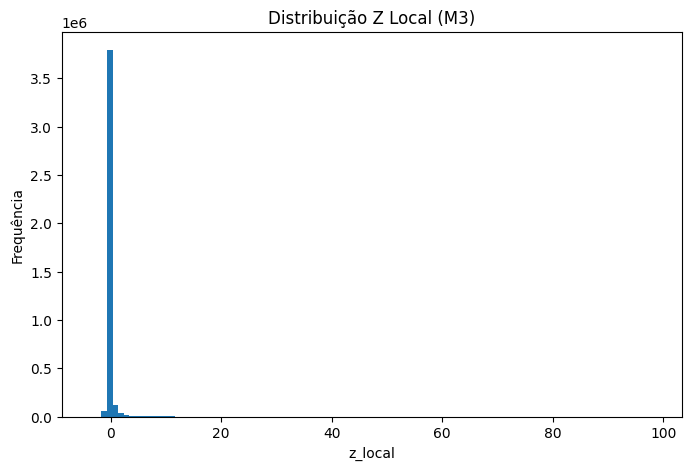

In [25]:
# =========================================
# M3 — MICRO 
# =========================================

# janela por contrato
w_local = Window.partitionBy("Número Contrato")

# média e desvio por contrato
df_feat = df_feat.withColumn("mean_local", F.avg("value").over(w_local))
df_feat = df_feat.withColumn("std_local", F.stddev("value").over(w_local))

# z-score local CORRETO
df_feat = df_feat.withColumn(
    "z_local",
    F.when(col("std_local") > 0,
           (col("value") - col("mean_local")) / col("std_local")
    ).otherwise(0)
)

# =========================================
# VISUALIZAÇÃO
# =========================================

pdf_micro = df_feat.select("z_local").dropna().toPandas()

plt.figure(figsize=(8,5))
plt.hist(pdf_micro["z_local"], bins=100)
plt.title("Distribuição Z Local (M3)")
plt.xlabel("z_local")
plt.ylabel("Frequência")
plt.show()

26/04/15 00:28:19 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/04/15 00:28:19 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/04/15 00:28:19 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/04/15 00:28:19 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/04/15 00:28:19 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/04/15 00:28:19 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/04/15 00:28:19 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/04/15 00:28:19 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/04/15 00:28:19 WARN RowBasedKeyValueBatch: Calling spill() on

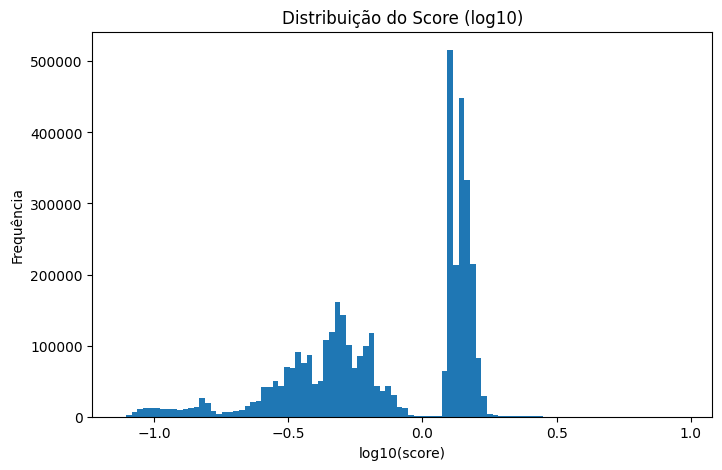

26/04/15 00:29:28 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/04/15 00:29:28 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/04/15 00:29:28 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/04/15 00:29:28 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/04/15 00:29:28 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/04/15 00:29:28 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/04/15 00:29:28 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/04/15 00:29:28 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/04/15 00:29:28 WARN RowBasedKeyValueBatch: Calling spill() on

In [30]:
# =========================================
# M4 — SCORE
# =========================================

# -------- limpeza preventiva --------
if "freq_value" in df_feat.columns:
    df_feat = df_feat.drop("freq_value")

# -------- distância de arredondamento --------
df_feat = df_feat.withColumn(
    "round_dist",
    F.abs(col("value") - (F.round(col("value") / 100) * 100)) / 100
)

# freq
freq_df = df_feat.groupBy("value").count().withColumnRenamed("count", "freq_value")

df_feat = df_feat.drop("freq_value")
df_feat = df_feat.join(freq_df, "value")

# max global SEM window
max_freq = df_feat.agg(F.max("freq_value")).collect()[0][0]

# features
df_feat = df_feat.withColumn("Z_norm", F.abs(col("Z")) / 10)
df_feat = df_feat.withColumn("z_local_norm", F.abs(col("z_local")) / 3)
df_feat = df_feat.withColumn("freq_norm", col("freq_value") / F.lit(max_freq))
df_feat = df_feat.withColumn("round_norm", 1 - col("round_dist"))
df_feat = df_feat.withColumn("ld_norm", col("ld_score"))

# fillna
df_feat = df_feat.fillna(0)

# score
df_feat = df_feat.withColumn(
    "score",
    0.30*col("Z_norm") +
    0.25*col("z_local_norm") +
    0.20*col("freq_norm") +
    0.15*col("round_norm") +
    0.10*col("ld_norm")
)

# =========================================
# VISUALIZAÇÃO
# =========================================

pdf_score = df_feat.select("score").dropna().toPandas()

pdf_score = pdf_score[np.isfinite(pdf_score["score"])]
pdf_score = pdf_score[pdf_score["score"] > 0]

plt.figure(figsize=(8,5))
plt.hist(np.log10(pdf_score["score"] + 1e-6), bins=100)
plt.title("Distribuição do Score (log10)")
plt.xlabel("log10(score)")
plt.ylabel("Frequência")
plt.show()

# =========================================
# 🚨 DETECÇÃO FINAL
# =========================================

threshold = df_feat.select("score").sample(0.2).approxQuantile("score", [0.85], 0.05)[0]

df_result = df_feat.withColumn(
    "suspeito",
    col("score") > threshold
)

26/04/15 00:30:21 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/04/15 00:30:21 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/04/15 00:30:21 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/04/15 00:30:21 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/04/15 00:30:21 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/04/15 00:30:21 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/04/15 00:30:21 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/04/15 00:30:21 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/04/15 00:30:21 WARN RowBasedKeyValueBatch: Calling spill() on

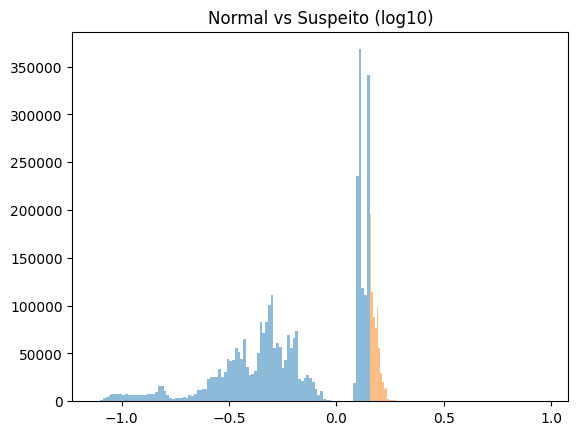

26/04/15 00:30:58 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/04/15 00:30:58 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/04/15 00:30:58 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/04/15 00:30:58 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/04/15 00:30:58 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/04/15 00:30:58 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/04/15 00:30:58 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/04/15 00:30:58 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/04/15 00:30:58 WARN RowBasedKeyValueBatch: Calling spill() on

+---------------+-------------+------------------+
|Número Contrato|value        |score             |
+---------------+-------------+------------------+
|000012024      |1.04624097E10|9.44174191180353  |
|000022024      |7.7253158E8  |8.171598543185738 |
|000082021      |1.969E8      |7.11222135513731  |
|000022023      |2.60000704E8 |6.882450108744628 |
|000022023      |2.60000704E8 |6.882450108744628 |
|000042024      |1.18999496E8 |6.8684110497395885|
|000092024      |2.29006608E8 |6.769869882402406 |
|000032018      |1.8477272E8  |6.743007504521237 |
|000082024      |1.4780928E8  |6.6646030068885445|
|52015          |5.235E8      |6.373472871312557 |
|52015          |5.235E8      |6.373472871312557 |
|62013          |1.87602608E8 |6.3560923285853566|
|62013          |1.87602608E8 |6.3560923285853566|
|62013          |1.87602608E8 |6.3560923285853566|
|62013          |1.87602608E8 |6.3560923285853566|
|000042020      |2.28724816E8 |6.0606866218821525|
|000042020      |2.28724816E8 |

26/04/15 00:31:30 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/04/15 00:31:30 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/04/15 00:31:30 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/04/15 00:31:30 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/04/15 00:31:30 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/04/15 00:31:30 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/04/15 00:31:30 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/04/15 00:31:30 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/04/15 00:31:30 WARN RowBasedKeyValueBatch: Calling spill() on

+--------+--------+------------------+------------------+
|suspeito|count(1)|        avg(value)|        avg(score)|
+--------+--------+------------------+------------------+
|    true|  722427| 995064.7983547059|1.5226527068791442|
|   false| 3328191|212815.07184343506| 0.756918749349729|
+--------+--------+------------------+------------------+



In [31]:
# -------- VISUALIZAÇÃO FINAL --------
pdf_final = df_result.select("score", "suspeito").toPandas()

plt.hist(np.log10(pdf_final[pdf_final["suspeito"]==False]["score"] + 1e-6), bins=100, alpha=0.5)
plt.hist(np.log10(pdf_final[pdf_final["suspeito"]==True]["score"] + 1e-6), bins=100, alpha=0.5)
plt.title("Normal vs Suspeito (log10)")
plt.show()

# =========================================
# OUTPUT FINAL
# =========================================
df_result.filter(col("suspeito")) \
    .orderBy(F.desc("score")) \
    .select("Número Contrato", "value", "score") \
    .show(20, False)

df_result.groupBy("suspeito").agg(
    F.count("*"),
    F.avg("value"),
    F.avg("score")
).show()